In [1]:
import sys
sys.path.append("..\\") # parent directory
from AQUA_general import AQUA
from batchAQUA_general import batchAQUA
from stimulus import *
from plotting_functions import *
from phase_response import *


import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [2]:
RS = {'name': 'RS', 'C': 100, 'k': 0.7, 'v_r': -60, 'v_t': -40, 'v_peak': 35,
    'a': 0.03, 'b': -2, 'c': -50, 'd': 100, 'e': 0.0, 'f': 0.0, 'tau': 0.0}

RS_E = {'name': 'RS', 'C': 100, 'k': 0.7, 'v_r': -60, 'v_t': -40, 'v_peak': 35,
    'a': 0.03, 'b': -2, 'c': -50, 'd': 100, 'e': 0.03, 'f': 8.0, 'tau': 0.5}

RS_I = {'name': 'RS', 'C': 100, 'k': 0.7, 'v_r': -60, 'v_t': -40, 'v_peak': 35,
    'a': 0.03, 'b': -2, 'c': -50, 'd': 100, 'e': 0.03, 'f': -8.0, 'tau': 0.5}

In [8]:
x_start = np.array([-65, 0, 0])
t_start = np.array([0.])

T = 2000
dt = 0.01
N_iter = int(T/dt)

I_inj = 100 * np.ones(N_iter)

neuron_RS = AQUA(RS)
neuron_RS.Initialise(x_start, t_start)

neuron_E = AQUA(RS_E)
neuron_E.Initialise(x_start, t_start)

neuron_I = AQUA(RS_I)
neuron_I.Initialise(x_start, t_start)

X, T, spikes = neuron_RS.update_RK2(dt, N_iter, I_inj)
X_E, T, spikes_E = neuron_E.update_RK2(dt, N_iter, I_inj)
X_I, T, spikes_I = neuron_I.update_RK2(dt, N_iter, I_inj)


100%|██████████| 199999/199999 [00:02<00:00, 79714.11it/s]


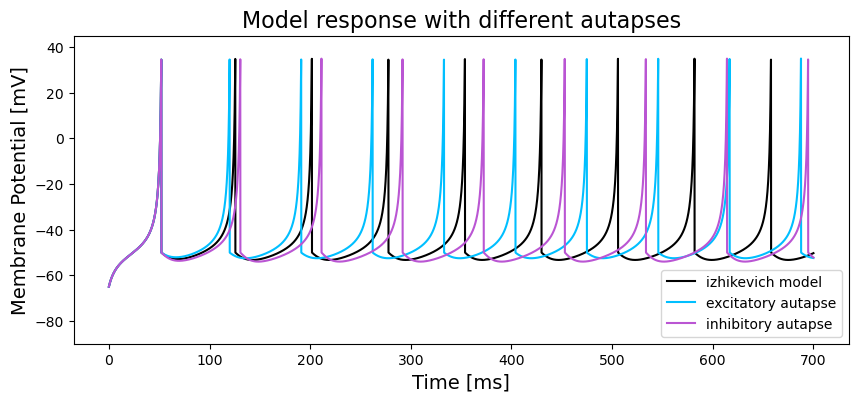

In [9]:
fig, ax = plt.subplots(1, 1, figsize = (10, 4))
indices = np.arange(70000)
ax.plot(T[indices], X[0, indices], c = 'black', label = "izhikevich model")
ax.plot(T[indices], X_E[0, indices], c = 'deepskyblue', label = "excitatory autapse")
ax.plot(T[indices], X_I[0, indices], c = 'mediumorchid', label = "inhibitory autapse")
ax.set_ylim(-90, 45)
ax.set_xlabel("Time [ms]", fontsize = 14)
ax.set_ylabel("Membrane Potential [mV]", fontsize = 14)
ax.set_title("Model response with different autapses", fontsize = 16)
plt.legend(loc = "lower right")
plt.savefig("model_response_example.svg", bbox_inches = 'tight')
plt.show()



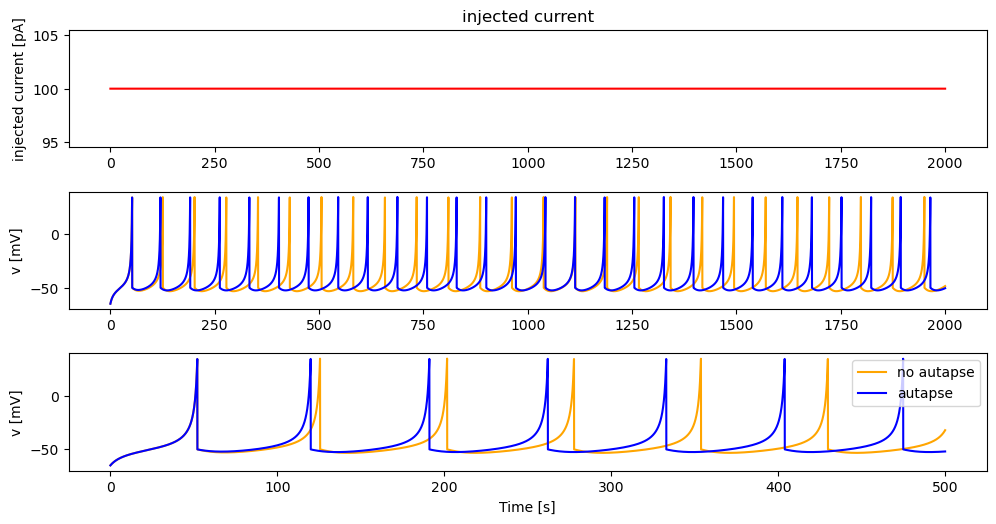

In [5]:
fig, ax = compare_trains(X[0, :], X_E[0, :], T, I_inj, indices = np.arange(50000))